In [1]:
# auto reload modules
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from cns.process import group_samples, add_total_cn
from cns.analyze import fig_lines, fig_dots,  fig_dots, plot_dots
from cns.data_utils import  main_load, load_samples_out, save_cns_fig, select_cns_by_type
from cns.utils import calc_mid

plt.rcParams.update({'font.size': 12})

c:\Python39\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [3]:
tcga_samples = load_samples_out("TCGA_hg19_samples.tsv")
len(tcga_samples[tcga_samples["type"] == 'LUAD']) 

458

In [4]:
samples_df, cns_df = main_load("1MB")
datasets = samples_df["source"].unique()

In [26]:
def first_name(name):
    return name.split("_")[0]

In [32]:
datasets = ["PCAWG", "TRACERx", "TCGA_hg19"]
luad_dict = { f'{first_name(k)} LUAD': select_cns_by_type(cns_df, samples_df.query(f"source == '{k}'"), "LUAD") for k in datasets }
lusc_dict = { f'{first_name(k)} LUSC': select_cns_by_type(cns_df, samples_df.query(f"source == '{k}'"), "LUSC") for k in datasets }
all_dict = luad_dict | lusc_dict
means_single = pd.concat([add_total_cn(group_samples(v, group_name=k)) for k, v in all_dict.items()])

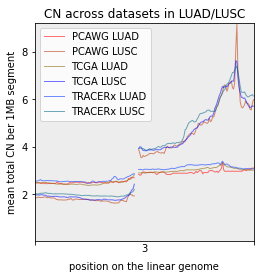

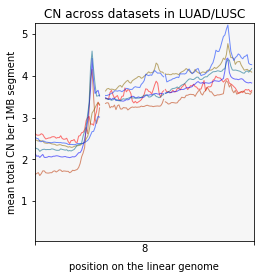

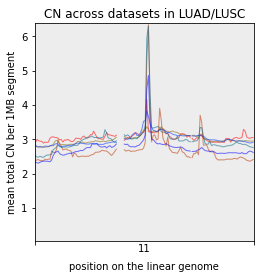

In [33]:
colors = ["#FF0000", "#BB3300", "#886600", "#0000FF", "#0033FF", "#006688"]
chroms = ["chr3", "chr8", "chr11"]
for chrom in chroms:
	fig, ax = fig_lines(means_single.query(f"chrom == '{chrom}'"), cn_columns="total_cn", colors=colors)
	fig.set_size_inches(4, 4)
	ax.set_ylabel("mean total CN ber 1MB segment")
	ax.set_title("CN across datasets in LUAD/LUSC")
	if chrom == "chr3":
		ax.legend(loc='upper left')
	else:
		# disable legend
		ax.legend().set_visible(False)
	save_cns_fig(f"fig_LUAD_LUSC_single_{chrom}")

In [35]:
# pearson correlation of means_single[0]["total_cn"] and means_single[1]["total_cn"]
datasets = ["PCAWG", "TRACERx", "TCGA"]
print("Correlations on 1 Mb segments between datasets")
correlations = []
for ctype in ["LUAD", "LUSC"]:
    for i in datasets:
        for j in datasets:
            first = f"{i} {ctype}"
            second = f"{j} {ctype}"
            corr = means_single.query(f"sample_id == '{i} {ctype}'")["total_cn"].corr(
                means_single.query(f"sample_id == '{j} {ctype}'")["total_cn"], method="pearson"
            )
            correlations.append((i, j, ctype, corr))

corr_df = pd.DataFrame(correlations, columns=["first", "second", "type", "corr"])
print(corr_df)

Correlations on 1 Mb segments between datasets
      first   second  type      corr
0     PCAWG    PCAWG  LUAD  1.000000
1     PCAWG  TRACERx  LUAD  0.766978
2     PCAWG     TCGA  LUAD  0.832256
3   TRACERx    PCAWG  LUAD  0.766978
4   TRACERx  TRACERx  LUAD  1.000000
5   TRACERx     TCGA  LUAD  0.811373
6      TCGA    PCAWG  LUAD  0.832256
7      TCGA  TRACERx  LUAD  0.811373
8      TCGA     TCGA  LUAD  1.000000
9     PCAWG    PCAWG  LUSC  1.000000
10    PCAWG  TRACERx  LUSC  0.885116
11    PCAWG     TCGA  LUSC  0.965726
12  TRACERx    PCAWG  LUSC  0.885116
13  TRACERx  TRACERx  LUSC  1.000000
14  TRACERx     TCGA  LUSC  0.892662
15     TCGA    PCAWG  LUSC  0.965726
16     TCGA  TRACERx  LUSC  0.892662
17     TCGA     TCGA  LUSC  1.000000


In [36]:
_, cosmic_df = main_load("COSMIC")
cosmic_group = group_samples(cosmic_df)

In [37]:
cosmic_lusc_group = add_total_cn(group_samples(select_cns_by_type(cosmic_df, samples_df, "LUSC"), group_name="COSMIC LUSC"))
cosmic_luad_group = add_total_cn(group_samples(select_cns_by_type(cosmic_df, samples_df, "LUAD"), group_name="COSMIC LUAD"))

In [38]:
# Plot the top attributions
cosmic_lusc_group.sort_values("total_cn", ascending=False).head()

,chrom,start,end,name,major_cn,minor_cn,sample_id,total_cn
482,chr3,181429713,181432221,SOX2,5.761044,1.800201,COSMIC LUSC,7.561245
481,chr3,178865901,178957881,PIK3CA,5.122490,1.792169,COSMIC LUSC,6.914659
480,chr3,176737142,176915261,TBL1XR1,4.956827,1.794177,COSMIC LUSC,6.751004
483,chr3,185000728,185206885,MAP3K13,4.811245,1.726908,COSMIC LUSC,6.538153
484,chr3,185361526,185542844,IGF2BP2,4.729920,1.716867,COSMIC LUSC,6.446787


In [39]:
# Plot the neighbours of SOX2
cosmic_lusc_group.query("chrom == 'chr3'").query("start > 175000000").head()

,chrom,start,end,name,major_cn,minor_cn,sample_id,total_cn
480,chr3,176737142,176915261,TBL1XR1,4.956827,1.794177,COSMIC LUSC,6.751004
481,chr3,178865901,178957881,PIK3CA,5.122490,1.792169,COSMIC LUSC,6.914659
482,chr3,181429713,181432221,SOX2,5.761044,1.800201,COSMIC LUSC,7.561245
483,chr3,185000728,185206885,MAP3K13,4.811245,1.726908,COSMIC LUSC,6.538153
484,chr3,185361526,185542844,IGF2BP2,4.729920,1.716867,COSMIC LUSC,6.446787


TBL1XR1 669276195 6.7510040160642575
PIK3CA 671361885 6.914658634538153
SOX2 673880961 7.561244979919678
EIF4A2 678954335 6.16566265060241
MUC4 687956385 5.865461847389558


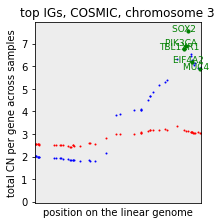

In [54]:
from cns import hg19

fig, ax = fig_dots(cosmic_lusc_group.query("chrom == 'chr3'"), cn_columns="total_cn")
plot_dots(ax, cosmic_luad_group.query("chrom == 'chr3'"), cn_column="total_cn", color="red")
genes = ['EIF4A2', 'SOX2', 'TBL1XR1', 'PIK3CA', "MUC4"]

positions = {
    'EIF4A2': (0, 0),
    'SOX2': (0, 0),
    'TBL1XR1': (0, 0),
    'PIK3CA': (0, 0),
    "MUC4": (0, 0)
}

for i, row in cosmic_lusc_group.iterrows():
    if row['name'] in genes:
        mid = calc_mid(row) + hg19.chr_starts["chr3"]
        plt.scatter(mid, row['total_cn'], color='green', s=10)
        print(row['name'], mid, row['total_cn'])
        text = f"{row['name']}"
        x, y = positions[row['name']]
        plt.text(mid + x * 10**8, row['total_cn'] + y, text + "   ", color="green", size=9, ha='center')


ax.set_ylabel("total CN per gene across samples")
plt.title("top IGs, COSMIC, chromosome 3")
save_cns_fig(f"fig_COSMIC_dots_IG_att_chr3")

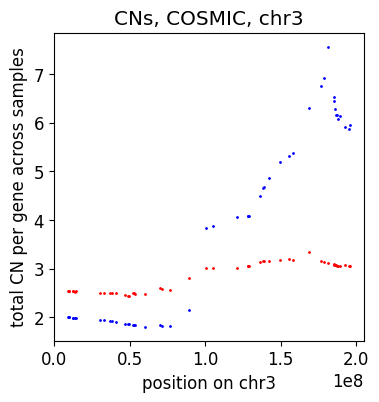

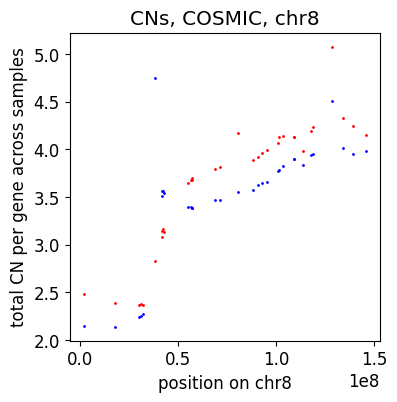

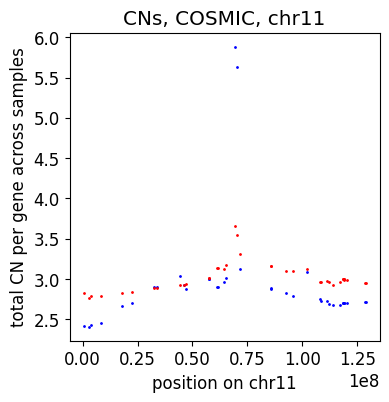

In [ ]:
for chrom in chroms:
    fig, ax = fig_dots(cosmic_lusc_group, chrom=chrom, cn_columns="total_cn")
    plot_dots(ax, cosmic_luad_group, chrom=chrom, column="total_cn", color="red")

    ax.set_ylabel("total CN per gene across samples")
    plt.title(f"CNs, COSMIC, {chrom}")
    save_cns_fig(f"fig_COSMIC_IG_att_{chrom}")

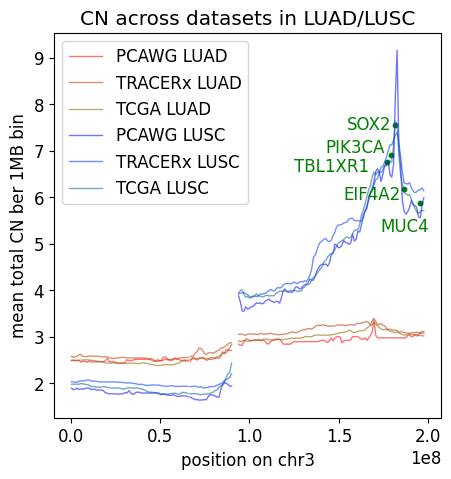

In [ ]:
labels = ["PCAWG LUAD", "TRACERx LUAD", "TCGA LUAD", "PCAWG LUSC", "TRACERx LUSC", "TCGA LUSC"]
fig, ax = fig_lines(means_single, labels, cn_columns="total_cn", color=["#FF0000", "#BB3300", "#886600", "#0000FF", "#0033FF", "#006688"],  chrom="chr3")
ax.set_ylabel("mean total CN ber 1MB bin")
ax.set_title("CN across datasets in LUAD/LUSC")
ax.legend(loc='upper left')
fig.set_size_inches(5, 5) 

offsets = {
    'EIF4A2': (-.2, -.1),
    'SOX2': (-.2, 0),
    'TBL1XR1': (-1, -.1),
    'PIK3CA': (-.3, .15),
    "MUC4": (.5, -.5)
}

for i, row in cosmic_lusc_group.iterrows():
    if row['name'] in ['EIF4A2', 'SOX2', 'TBL1XR1', 'PIK3CA', "MUC4"]:
        mid = calc_mid(row)
        plt.scatter(mid, row['total_cn'], color='green', s=10)
        name = row['name']
        x, y = offsets[name]
        plt.text(mid + x*10**7, row['total_cn'] + y, name, color="green", size=12, ha='right', va='center')

save_cns_fig(f"fig_COSMIC_lines_IG_att_chr3")